In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from tensorflow import keras

In [2]:
df = pd.read_csv("synthetic_ecommerce_order_risk_dataset.csv")

In [3]:
df.head()

,order_id,order_date,country,device_type,traffic_source,payment_method,product_category,customer_age_days,previous_orders,avg_order_value_eur,...,shipping_distance_km,delivery_days_estimated,late_delivery_risk,address_mismatch,high_risk_ip,customer_support_contacts,review_score,is_returned,is_fraud,risk_label
0,ORD-2024-001936,2024-01-03,Belgium,Mobile,Paid Ads,Credit Card,Sports,381,3,28.66,...,105.7,5,0,0,0,0,4.4,0,0,Normal
1,ORD-2025-006495,2025-11-26,Netherlands,Desktop,Email,Debit Card,Garden,561,6,41.93,...,528.2,4,0,0,0,0,4.8,0,0,Normal
2,ORD-2023-001721,2023-11-07,Netherlands,Mobile,Organic Search,Debit Card,Garden,324,2,102.67,...,175.1,5,0,0,0,0,3.3,0,0,Normal
3,ORD-2024-009121,2024-05-28,Netherlands,Mobile,Organic Search,Klarna,Electronics,378,3,72.71,...,271.4,3,0,0,0,0,4.2,1,0,Return Risk
4,ORD-2025-000361,2025-01-31,Netherlands,Desktop,Direct,Bank Transfer,Home & Kitchen,447,5,52.26,...,285.3,3,0,1,0,0,5.0,0,0,Normal


In [4]:
df.tail()

,order_id,order_date,country,device_type,traffic_source,payment_method,product_category,customer_age_days,previous_orders,avg_order_value_eur,...,shipping_distance_km,delivery_days_estimated,late_delivery_risk,address_mismatch,high_risk_ip,customer_support_contacts,review_score,is_returned,is_fraud,risk_label
11995,ORD-2023-011965,2023-02-19,France,Mobile,Social Media,Credit Card,Garden,742,3,25.75,...,121.4,3,0,0,0,1,4.5,0,0,Normal
11996,ORD-2023-005192,2023-05-12,France,Mobile,Organic Search,Debit Card,Fashion,152,1,96.29,...,225.5,4,0,0,0,0,5.0,0,0,Normal
11997,ORD-2024-005391,2024-06-13,Germany,Mobile,Organic Search,Credit Card,Fashion,130,0,114.14,...,669.6,5,0,0,0,0,4.5,0,0,Normal
11998,ORD-2025-000861,2025-04-04,Poland,Desktop,Marketplace,PayPal,Fashion,203,1,21.60,...,229.4,5,0,0,0,0,4.4,0,0,Normal
11999,ORD-2024-007271,2024-05-23,Netherlands,Desktop,Organic Search,PayPal,Beauty,288,2,35.58,...,406.6,3,0,0,0,1,3.7,0,0,Normal


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 23 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   order_id                   12000 non-null  object 
 1   order_date                 12000 non-null  object 
 2   country                    12000 non-null  object 
 3   device_type                12000 non-null  object 
 4   traffic_source             12000 non-null  object 
 5   payment_method             12000 non-null  object 
 6   product_category           12000 non-null  object 
 7   customer_age_days          12000 non-null  int64  
 8   previous_orders            12000 non-null  int64  
 9   avg_order_value_eur        12000 non-null  float64
 10  order_value_eur            12000 non-null  float64
 11  quantity                   12000 non-null  int64  
 12  discount_rate              12000 non-null  float64
 13  shipping_distance_km       12000 non-null  flo

In [6]:
df.isna().sum()

,0
order_id,0
order_date,0
country,0
device_type,0
traffic_source,0
payment_method,0
product_category,0
customer_age_days,0
previous_orders,0
avg_order_value_eur,0


In [7]:
df.describe()

,customer_age_days,previous_orders,avg_order_value_eur,order_value_eur,quantity,discount_rate,shipping_distance_km,delivery_days_estimated,late_delivery_risk,address_mismatch,high_risk_ip,customer_support_contacts,review_score,is_returned,is_fraud
count,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000
mean,352.789083,1.943417,48.940278,61.053339,2.171833,0.146857,479.196567,4.058917,0.060000,0.048583,0.044167,0.200667,4.412433,0.092667,0.037250
std,237.556088,1.902590,28.716864,55.540429,1.625534,0.113934,330.305205,1.105312,0.237497,0.215004,0.205474,0.478803,0.545286,0.289977,0.189382
min,5.000000,0.000000,8.000000,5.000000,1.000000,0.000000,5.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.300000,0.000000,0.000000
25%,177.000000,1.000000,29.070000,26.617500,1.000000,0.060000,236.100000,3.000000,0.000000,0.000000,0.000000,0.000000,4.100000,0.000000,0.000000
50%,299.000000,1.000000,42.100000,45.335000,2.000000,0.120000,404.450000,4.000000,0.000000,0.000000,0.000000,0.000000,4.500000,0.000000,0.000000
75%,475.000000,3.000000,61.010000,75.952500,3.000000,0.210000,645.225000,5.000000,0.000000,0.000000,0.000000,0.000000,4.900000,0.000000,0.000000
max,1832.000000,13.000000,350.450000,810.750000,8.000000,0.750000,2589.700000,9.000000,1.000000,1.000000,1.000000,5.000000,5.000000,1.000000,1.000000


In [8]:
from tensorflow.keras import layers

In [9]:
df['risk_label'].unique()

array(['Normal', 'Return Risk', 'Fraud Risk'], dtype=object)

In [10]:
risk_order = ['Normal', 'Return Risk', 'Fraud Risk']

In [11]:
X = df.drop(['risk_label', 'is_fraud', 'is_returned',
             'high_risk_ip', 'address_mismatch', 'late_delivery_risk'], axis = 1)
y = df['risk_label']

In [12]:
from sklearn.preprocessing import LabelEncoder

In [13]:
label_encoding = LabelEncoder()

In [14]:
y_encoded = label_encoding.fit_transform(y)

In [15]:
y_encoded

array([1, 1, 1, ..., 1, 1, 1])

In [16]:
X

,order_id,order_date,country,device_type,traffic_source,payment_method,product_category,customer_age_days,previous_orders,avg_order_value_eur,order_value_eur,quantity,discount_rate,shipping_distance_km,delivery_days_estimated,customer_support_contacts,review_score
0,ORD-2024-001936,2024-01-03,Belgium,Mobile,Paid Ads,Credit Card,Sports,381,3,28.66,33.71,2,0.12,105.7,5,0,4.4
1,ORD-2025-006495,2025-11-26,Netherlands,Desktop,Email,Debit Card,Garden,561,6,41.93,73.29,3,0.03,528.2,4,0,4.8
2,ORD-2023-001721,2023-11-07,Netherlands,Mobile,Organic Search,Debit Card,Garden,324,2,102.67,55.49,1,0.05,175.1,5,0,3.3
3,ORD-2024-009121,2024-05-28,Netherlands,Mobile,Organic Search,Klarna,Electronics,378,3,72.71,112.54,5,0.22,271.4,3,0,4.2
4,ORD-2025-000361,2025-01-31,Netherlands,Desktop,Direct,Bank Transfer,Home & Kitchen,447,5,52.26,55.32,8,0.25,285.3,3,0,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11995,ORD-2023-011965,2023-02-19,France,Mobile,Social Media,Credit Card,Garden,742,3,25.75,25.75,1,0.31,121.4,3,1,4.5
11996,ORD-2023-005192,2023-05-12,France,Mobile,Organic Search,Debit Card,Fashion,152,1,96.29,118.35,2,0.09,225.5,4,0,5.0
11997,ORD-2024-005391,2024-06-13,Germany,Mobile,Organic Search,Credit Card,Fashion,130,0,114.14,114.13,1,0.08,669.6,5,0,4.5
11998,ORD-2025-000861,2025-04-04,Poland,Desktop,Marketplace,PayPal,Fashion,203,1,21.60,25.58,1,0.23,229.4,5,0,4.4


In [17]:
import seaborn as sns

In [18]:
categorical_cols = df.select_dtypes(include=['object', 'category']).columns

In [19]:
categorical_cols

Index(['order_id', 'order_date', 'country', 'device_type', 'traffic_source',
       'payment_method', 'product_category', 'risk_label'],
      dtype='object')

In [20]:
col_drop = ['order_id', 'order_date']

In [21]:
df = df.drop(col_drop, axis = 1)

In [22]:
df.head()

,country,device_type,traffic_source,payment_method,product_category,customer_age_days,previous_orders,avg_order_value_eur,order_value_eur,quantity,...,shipping_distance_km,delivery_days_estimated,late_delivery_risk,address_mismatch,high_risk_ip,customer_support_contacts,review_score,is_returned,is_fraud,risk_label
0,Belgium,Mobile,Paid Ads,Credit Card,Sports,381,3,28.66,33.71,2,...,105.7,5,0,0,0,0,4.4,0,0,Normal
1,Netherlands,Desktop,Email,Debit Card,Garden,561,6,41.93,73.29,3,...,528.2,4,0,0,0,0,4.8,0,0,Normal
2,Netherlands,Mobile,Organic Search,Debit Card,Garden,324,2,102.67,55.49,1,...,175.1,5,0,0,0,0,3.3,0,0,Normal
3,Netherlands,Mobile,Organic Search,Klarna,Electronics,378,3,72.71,112.54,5,...,271.4,3,0,0,0,0,4.2,1,0,Return Risk
4,Netherlands,Desktop,Direct,Bank Transfer,Home & Kitchen,447,5,52.26,55.32,8,...,285.3,3,0,1,0,0,5.0,0,0,Normal


In [23]:
X = df.drop(['risk_label'], axis = 1)
y = df['risk_label']

In [24]:
categorical_cols = df.select_dtypes(include=['object', 'category']).columns

In [25]:
categorical_cols

Index(['country', 'device_type', 'traffic_source', 'payment_method',
       'product_category', 'risk_label'],
      dtype='object')

In [26]:
neuron = 0
for col in categorical_cols:
  neuron += df[col].nunique()

print(neuron)

34


In [27]:
num_cols = df.select_dtypes(exclude=['object', 'category']).columns

In [28]:
num_cols

Index(['customer_age_days', 'previous_orders', 'avg_order_value_eur',
       'order_value_eur', 'quantity', 'discount_rate', 'shipping_distance_km',
       'delivery_days_estimated', 'late_delivery_risk', 'address_mismatch',
       'high_risk_ip', 'customer_support_contacts', 'review_score',
       'is_returned', 'is_fraud'],
      dtype='object')

In [29]:
len(num_cols)

15

In [30]:
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
customer_age_days,12000.0,352.789083,237.556088,5.0,177.0000,299.000,475.0000,1832.00
previous_orders,12000.0,1.943417,1.902590,0.0,1.0000,1.000,3.0000,13.00
avg_order_value_eur,12000.0,48.940278,28.716864,8.0,29.0700,42.100,61.0100,350.45
order_value_eur,12000.0,61.053339,55.540429,5.0,26.6175,45.335,75.9525,810.75
quantity,12000.0,2.171833,1.625534,1.0,1.0000,2.000,3.0000,8.00
discount_rate,12000.0,0.146857,0.113934,0.0,0.0600,0.120,0.2100,0.75
shipping_distance_km,12000.0,479.196567,330.305205,5.0,236.1000,404.450,645.2250,2589.70
delivery_days_estimated,12000.0,4.058917,1.105312,1.0,3.0000,4.000,5.0000,9.00
late_delivery_risk,12000.0,0.060000,0.237497,0.0,0.0000,0.000,0.0000,1.00
address_mismatch,12000.0,0.048583,0.215004,0.0,0.0000,0.000,0.0000,1.00


In [31]:
from tensorflow.keras.layers import Normalization, Dense
from tensorflow.keras.models import Sequential

In [32]:
df.head()

,country,device_type,traffic_source,payment_method,product_category,customer_age_days,previous_orders,avg_order_value_eur,order_value_eur,quantity,...,shipping_distance_km,delivery_days_estimated,late_delivery_risk,address_mismatch,high_risk_ip,customer_support_contacts,review_score,is_returned,is_fraud,risk_label
0,Belgium,Mobile,Paid Ads,Credit Card,Sports,381,3,28.66,33.71,2,...,105.7,5,0,0,0,0,4.4,0,0,Normal
1,Netherlands,Desktop,Email,Debit Card,Garden,561,6,41.93,73.29,3,...,528.2,4,0,0,0,0,4.8,0,0,Normal
2,Netherlands,Mobile,Organic Search,Debit Card,Garden,324,2,102.67,55.49,1,...,175.1,5,0,0,0,0,3.3,0,0,Normal
3,Netherlands,Mobile,Organic Search,Klarna,Electronics,378,3,72.71,112.54,5,...,271.4,3,0,0,0,0,4.2,1,0,Return Risk
4,Netherlands,Desktop,Direct,Bank Transfer,Home & Kitchen,447,5,52.26,55.32,8,...,285.3,3,0,1,0,0,5.0,0,0,Normal


In [33]:
y

,risk_label
0,Normal
1,Normal
2,Normal
3,Return Risk
4,Normal
...,...
11995,Normal
11996,Normal
11997,Normal
11998,Normal


In [34]:
X

,country,device_type,traffic_source,payment_method,product_category,customer_age_days,previous_orders,avg_order_value_eur,order_value_eur,quantity,discount_rate,shipping_distance_km,delivery_days_estimated,late_delivery_risk,address_mismatch,high_risk_ip,customer_support_contacts,review_score,is_returned,is_fraud
0,Belgium,Mobile,Paid Ads,Credit Card,Sports,381,3,28.66,33.71,2,0.12,105.7,5,0,0,0,0,4.4,0,0
1,Netherlands,Desktop,Email,Debit Card,Garden,561,6,41.93,73.29,3,0.03,528.2,4,0,0,0,0,4.8,0,0
2,Netherlands,Mobile,Organic Search,Debit Card,Garden,324,2,102.67,55.49,1,0.05,175.1,5,0,0,0,0,3.3,0,0
3,Netherlands,Mobile,Organic Search,Klarna,Electronics,378,3,72.71,112.54,5,0.22,271.4,3,0,0,0,0,4.2,1,0
4,Netherlands,Desktop,Direct,Bank Transfer,Home & Kitchen,447,5,52.26,55.32,8,0.25,285.3,3,0,1,0,0,5.0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11995,France,Mobile,Social Media,Credit Card,Garden,742,3,25.75,25.75,1,0.31,121.4,3,0,0,0,1,4.5,0,0
11996,France,Mobile,Organic Search,Debit Card,Fashion,152,1,96.29,118.35,2,0.09,225.5,4,0,0,0,0,5.0,0,0
11997,Germany,Mobile,Organic Search,Credit Card,Fashion,130,0,114.14,114.13,1,0.08,669.6,5,0,0,0,0,4.5,0,0
11998,Poland,Desktop,Marketplace,PayPal,Fashion,203,1,21.60,25.58,1,0.23,229.4,5,0,0,0,0,4.4,0,0


In [35]:
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

In [36]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=42)

In [37]:
for col in df.columns:
  print(f"Column: {col}")
  print(df[col].nunique())

Column: country
8
Column: device_type
3
Column: traffic_source
6
Column: payment_method
6
Column: product_category
8
Column: customer_age_days
1131
Column: previous_orders
14
Column: avg_order_value_eur
6467
Column: order_value_eur
7517
Column: quantity
8
Column: discount_rate
73
Column: shipping_distance_km
7086
Column: delivery_days_estimated
9
Column: late_delivery_risk
2
Column: address_mismatch
2
Column: high_risk_ip
2
Column: customer_support_contacts
6
Column: review_score
36
Column: is_returned
2
Column: is_fraud
2
Column: risk_label
3


In [38]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler

preprocessor = ColumnTransformer(
    transformers = [
        ('num', MinMaxScaler(), ["customer_age_days", "previous_orders",
                                 "avg_order_value_eur", "order_value_eur",
                                 "quantity", "discount_rate", "shipping_distance_km",
                                 "delivery_days_estimated", "customer_support_contacts",
                                 "review_score"]),
        ("cat", OneHotEncoder(sparse_output=False), ["country", "device_type",
                                                    "traffic_source","payment_method",
                                                     "product_category"]),
    ], remainder="passthrough",)

In [39]:
X_train_final = preprocessor.fit_transform(X_train)
X_test_final = preprocessor.transform(X_test)

In [40]:
X_train_final

array([[0.0651341 , 0.        , 0.16817054, ..., 0.        , 0.        ,
        0.        ],
       [0.05145047, 0.15384615, 0.09280187, ..., 0.        , 0.        ,
        0.        ],
       [0.10399562, 0.15384615, 0.35771645, ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.24028462, 0.38461538, 0.25957074, ..., 0.        , 1.        ,
        0.        ],
       [0.26163109, 0.07692308, 0.10614688, ..., 0.        , 0.        ,
        0.        ],
       [0.22058019, 0.23076923, 0.16998102, ..., 0.        , 0.        ,
        0.        ]])

In [41]:
X_train_final.shape[1]

46

In [42]:
model = Sequential([
    tf.keras.Input(shape=(46,)),
    Dense(64, activation = 'relu'),
    Dense(32, activation='relu'),
    Dense(3, activation='softmax')
])

In [43]:
y_train_final = ohe.fit_transform(y_train.values.reshape(-1, 1))
y_test_final = ohe.transform(y_test.values.reshape(-1, 1))

In [44]:
y.nunique()

3

In [45]:
model.compile(optimizer='adam',
              loss = 'categorical_crossentropy',
              metrics = ['accuracy'])

In [46]:
history = model.fit(
    X_train_final,
    y_train_final,
    epochs = 50,
    verbose = 2,
    batch_size=32,
    validation_data = (X_test_final, y_test_final)
)

Epoch 1/50
300/300 - 5s - 18ms/step - accuracy: 0.9311 - loss: 0.2312 - val_accuracy: 0.9992 - val_loss: 0.0148
Epoch 2/50
300/300 - 1s - 5ms/step - accuracy: 0.9997 - loss: 0.0050 - val_accuracy: 1.0000 - val_loss: 0.0026
Epoch 3/50
300/300 - 1s - 3ms/step - accuracy: 1.0000 - loss: 0.0012 - val_accuracy: 1.0000 - val_loss: 0.0010
Epoch 4/50
300/300 - 1s - 2ms/step - accuracy: 1.0000 - loss: 5.1564e-04 - val_accuracy: 1.0000 - val_loss: 5.7353e-04
Epoch 5/50
300/300 - 1s - 2ms/step - accuracy: 1.0000 - loss: 2.8467e-04 - val_accuracy: 1.0000 - val_loss: 3.2906e-04
Epoch 6/50
300/300 - 1s - 4ms/step - accuracy: 1.0000 - loss: 1.7492e-04 - val_accuracy: 1.0000 - val_loss: 2.1976e-04
Epoch 7/50
300/300 - 1s - 5ms/step - accuracy: 1.0000 - loss: 1.1664e-04 - val_accuracy: 1.0000 - val_loss: 1.5497e-04
Epoch 8/50
300/300 - 1s - 3ms/step - accuracy: 1.0000 - loss: 8.2166e-05 - val_accuracy: 1.0000 - val_loss: 1.0902e-04
Epoch 9/50
300/300 - 1s - 3ms/step - accuracy: 1.0000 - loss: 5.9490e-0

In [47]:
all_cols = set(X_train.columns)
listed_num = {"customer_age_days", "previous_orders", "avg_order_value_eur",
              "order_value_eur", "quantity", "discount_rate",
              "shipping_distance_km", "delivery_days_estimated",
              "customer_support_contacts", "review_score"}
listed_cat = {"country", "device_type", "traffic_source",
              "payment_method", "product_category"}

passthrough_cols = all_cols - listed_num - listed_cat
print("Leaky passthrough columns:", passthrough_cols)  # Should be empty!

Leaky passthrough columns: {'late_delivery_risk', 'high_risk_ip', 'address_mismatch', 'is_returned', 'is_fraud'}


In [48]:
# 1. What's still passing through?
all_cols = set(X_train.columns)
listed_num = {"customer_age_days", "previous_orders", "avg_order_value_eur",
              "order_value_eur", "quantity", "discount_rate",
              "shipping_distance_km", "delivery_days_estimated",
              "customer_support_contacts", "review_score"}
listed_cat = {"country", "device_type", "traffic_source",
              "payment_method", "product_category"}

print("Passthrough cols:", all_cols - listed_num - listed_cat)
print()

# 2. What does the data actually look like per class?
print(df.groupby('risk_label').mean(numeric_only=True).T)
print()

# 3. What's the class distribution?
print(df['risk_label'].value_counts())

Passthrough cols: {'late_delivery_risk', 'high_risk_ip', 'address_mismatch', 'is_returned', 'is_fraud'}

risk_label                 Fraud Risk      Normal  Return Risk
customer_age_days          282.357942  357.370540   337.345472
previous_orders              1.076063    1.996470     1.786181
avg_order_value_eur         47.341074   49.000923    49.014192
order_value_eur             60.361253   60.857591    63.258002
quantity                     2.172260    2.172486     2.165266
discount_rate                0.150761    0.144824     0.165126
shipping_distance_km       467.587248  477.347405   502.139869
delivery_days_estimated      4.053691    4.053520     4.113912
late_delivery_risk           0.053691    0.055810     0.103641
address_mismatch             0.190157    0.043408     0.040149
high_risk_ip                 0.214765    0.038161     0.031746
customer_support_contacts    0.214765    0.194142     0.258637
review_score                 4.410515    4.514472     3.414566
is_returned  

In [49]:
df.value_counts()

country  device_type  traffic_source  payment_method  product_category  customer_age_days  previous_orders  avg_order_value_eur  order_value_eur  quantity  discount_rate  shipping_distance_km  delivery_days_estimated  late_delivery_risk  address_mismatch  high_risk_ip  customer_support_contacts  review_score  is_returned  is_fraud  risk_label 
Turkey   Tablet       Paid Ads        Debit Card      Fashion           169                1                17.91                11.25            2         0.19           428.3                 4                        0                   0                 0             0                          4.5           0            0         Normal         1
                                      Credit Card     Pet Supplies      44                 0                76.24                38.29            1         0.04           694.1                 3                        0                   0                 0             0                          3.4           1            0         Return Risk    1
                                                      Home & Kitchen    526                6                33.78                37.90            7         0.28           343.6                 4                        0                   0                 0             0                          3.9           0            0         Normal         1
                                                                        367                3                25.06                23.06            3         0.27           864.4                 5                        0                   0                 0             0                          3.7           0            0         Normal         1
                                                      Fashion           144                0                66.79                39.07            1         0.27           507.9                 3                        0                   0                 0             1                          3.6           0            0         Normal         1
                                                                                                                                                                                                                                                                                                                                                            ..
Belgium  Desktop      Direct          Bank Transfer   Garden            220                1                51.48                22.67            1         0.09           401.4                 4                        0                   0                 0             0                          4.6           0            0         Normal         1
                                                      Electronics       391                1                84.53                177.28           2         0.05           384.5                 3                        0                   0                 0             0                          4.7           0            0         Normal         1
                                                                        341                1                61.85                73.82            2         0.07           99.4                  2                        0                   0                 0             0                          4.8           0            0         Normal         1
                                                      Beauty            459                4                123.84               53.07            4         0.04           547.3                 4                        0                   0                 0             0                          5.0           0            0         Normal         1
                                                                        103                2                45.66                22.64          

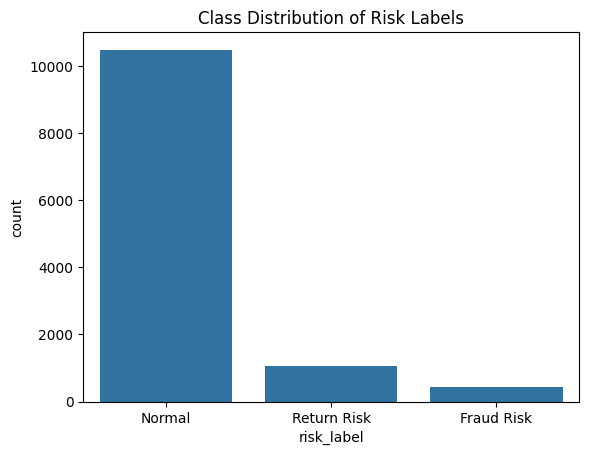

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(data=df, x='risk_label')
plt.title('Class Distribution of Risk Labels')
plt.show()

In [52]:
df['risk_label'].value_counts(normalize=True)*100

,proportion
risk_label,
Normal,87.350
Return Risk,8.925
Fraud Risk,3.725


In [55]:
from imblearn.under_sampling import RandomUnderSampler

rus = RandomUnderSampler(random_state = 42)

y_train_integers = np.argmax(y_train_final, axis= 1)

X_train_balanced, y_train_balanced_integers = rus.fit_resample(X_train_final, y_train_integers)

y_train_balanced_final = tf.keras.utils.to_categorical(y_train_balanced_integers, num_classes=3)

In [57]:
y_train_balanced_final.value_counts(normalize=True)*100

AttributeError: 'numpy.ndarray' object has no attribute 'value_counts'